#Data Understanding

## 1. Setup

This section imports the required libraries, configures the notebook environment and loads the dataset for analysis.[Click to access the datset](https://www.kaggle.com/datasets/abdallaahmed77/healthcare-risk-factors-dataset/data)

In [87]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import library for visualisation
import matplotlib.pyplot as plt

# Import display utilities
from IPython.display import display

# Configure display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [88]:
# Load the Healthcare Risk Factors Dataset directly from Google Drive

url = "https://drive.google.com/uc?export=download&id=172iXgtbQd_Xf0xMYJVM0GkdiYeVBi_I0"

df = pd.read_csv(url)

In [89]:
# Confirm that the dataset has loaded successfully

print("Dataset Loaded Successfully\n")

print(f"Number of Records : {df.shape[0]:,}")
print(f"Number of Features: {df.shape[1]}")

Dataset Loaded Successfully

Number of Records : 30,000
Number of Features: 20


## 2. Data Overview

This section provides an overview of the dataset, including its dimensions, variables, data types and summary statistics. Understanding these characteristics provides an initial assessment of the dataset before data quality checks are performed.

In [90]:
# Display the first five observations

display(df.head())

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.00,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.06
1,22.00,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.23
2,50.00,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.33
3,57.00,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.19
4,66.00,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.83


In [91]:
# Display the structure of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         30000 non-null  float64
 15  Family History     30000 non-null  int64  
 16  Stress Level       300

In [92]:
# Summarise the data types of all variables

data_types = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.values
})

display(data_types)

,Variable,Data Type
0,Age,float64
1,Gender,object
2,Medical Condition,object
3,Glucose,float64
4,Blood Pressure,float64
5,BMI,float64
6,Oxygen Saturation,float64
7,LengthOfStay,int64
8,Cholesterol,float64
9,Triglycerides,float64


In [93]:
# Generate descriptive statistics for numerical and categorical variables

display(df.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,25500.00,NaN,NaN,NaN,54.62,15.97,10.00,45.00,55.00,66.00,89.00
Gender,25500,2,Female,12865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,25500,7,Hypertension,7120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Glucose,25500.00,NaN,NaN,NaN,123.62,41.58,20.32,96.28,110.50,136.61,318.51
Blood Pressure,25500.00,NaN,NaN,NaN,140.46,21.08,74.24,125.14,138.32,153.79,226.38
BMI,30000.00,NaN,NaN,NaN,28.48,5.73,7.67,24.59,28.05,31.81,56.85
Oxygen Saturation,30000.00,NaN,NaN,NaN,94.95,3.74,67.51,93.00,95.30,97.38,110.07
LengthOfStay,30000.00,NaN,NaN,NaN,4.41,2.76,1.00,3.00,4.00,5.00,19.00
Cholesterol,30000.00,NaN,NaN,NaN,213.03,33.52,95.73,189.50,211.84,235.31,358.37
Triglycerides,30000.00,NaN,NaN,NaN,176.84,48.81,-22.48,141.28,173.37,208.63,421.51


### Define Project Constants

Key constants used throughout the notebook are defined below to improve readability, reduce repetition and simplify maintenance.

In [94]:
# Define the target variable

TARGET = "LengthOfStay"

# Define columns that do not contribute to prediction

NOISE_COLUMNS = [
    "random_notes",
    "noise_col"
]

### Interpretation

The dataset contains **30,000 patient records** and **20 variables**, including demographic, clinical and lifestyle information. The target variable, **LengthOfStay**, is numerical, confirming that this is a regression problem.

Most of the dataset is complete, although five variables contain approximately **15% missing values**. These missing values can be handled during preprocessing without removing a large number of records.

The dataset includes both numerical and categorical variables, meaning that some preprocessing, such as encoding categorical data, will be required before model training.

The summary statistics show good variation across the variables, which is beneficial for machine learning. Two variables, **random_notes** and **noise_col**, do not contain meaningful information and will be removed during preprocessing.

## 3. Data Quality Assessment

This section evaluates the quality of the dataset by identifying missing values, duplicate records and variables that may not contribute to predictive modelling.

In [95]:
# Summarise missing values for each variable

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing.sort_values(
    by="Percentage (%)",
    ascending=False
)

display(missing)

,Missing Values,Percentage (%)
Age,4500,15.00
Gender,4500,15.00
Medical Condition,4500,15.00
Glucose,4500,15.00
Blood Pressure,4500,15.00
BMI,0,0.00
Oxygen Saturation,0,0.00
LengthOfStay,0,0.00
Cholesterol,0,0.00
Triglycerides,0,0.00


In [96]:
# Check for duplicate records

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [97]:
# Display the predefined noise variables

print("Noise Variables Included in the Dataset:")

for column in NOISE_COLUMNS:
    print(f"• {column}")

Noise Variables Included in the Dataset:
• random_notes
• noise_col


## 4. Exploratory Data Analysis

This section explores the distribution of the target variable and the relationships between the predictor variables and hospital length of stay. The analysis provides an initial understanding of the data before preprocessing and model development.

In [98]:
# Configure visualisation settings

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

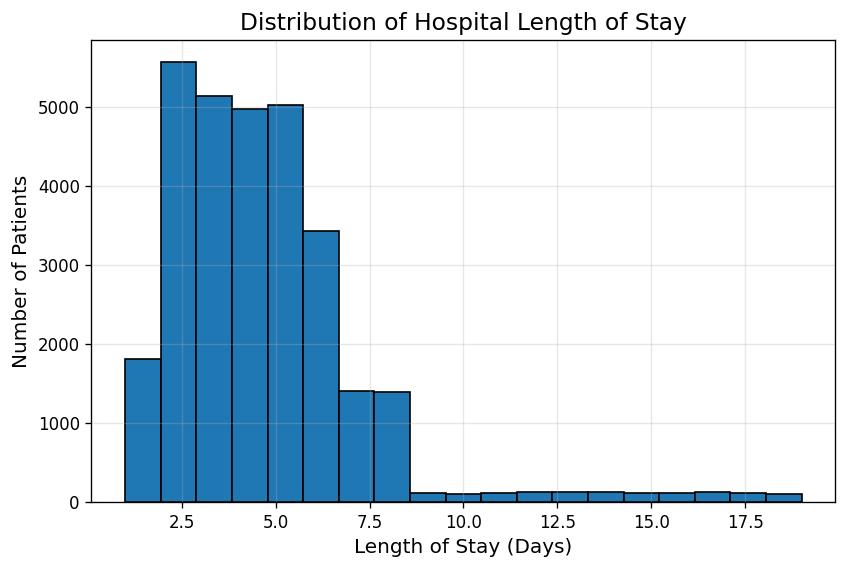

,Statistic,Value
0,Minimum,1.00
1,Maximum,19.00
2,Mean,4.41
3,Median,4.00
4,Standard Deviation,2.76


In [99]:
# Analyse the target variable

fig, ax = plt.subplots()

ax.hist(
    df[TARGET],
    bins=19,
    edgecolor="black"
)

ax.set_title("Distribution of Hospital Length of Stay")
ax.set_xlabel("Length of Stay (Days)")
ax.set_ylabel("Number of Patients")

plt.show()

# Display summary statistics

target_summary = pd.DataFrame({
    "Statistic": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Standard Deviation"
    ],
    "Value": [
        df[TARGET].min(),
        df[TARGET].max(),
        round(df[TARGET].mean(),2),
        df[TARGET].median(),
        round(df[TARGET].std(),2)
    ]
})

display(target_summary)

In [100]:
# Identify numerical variables for analysis

numerical_columns = (
    df
    .select_dtypes(include=["int64", "float64"])
    .columns
    .drop([TARGET, "noise_col"])
)

# Identify categorical variables for analysis

categorical_columns = (
    df
    .select_dtypes(include="object")
    .columns
    .drop("random_notes")
)


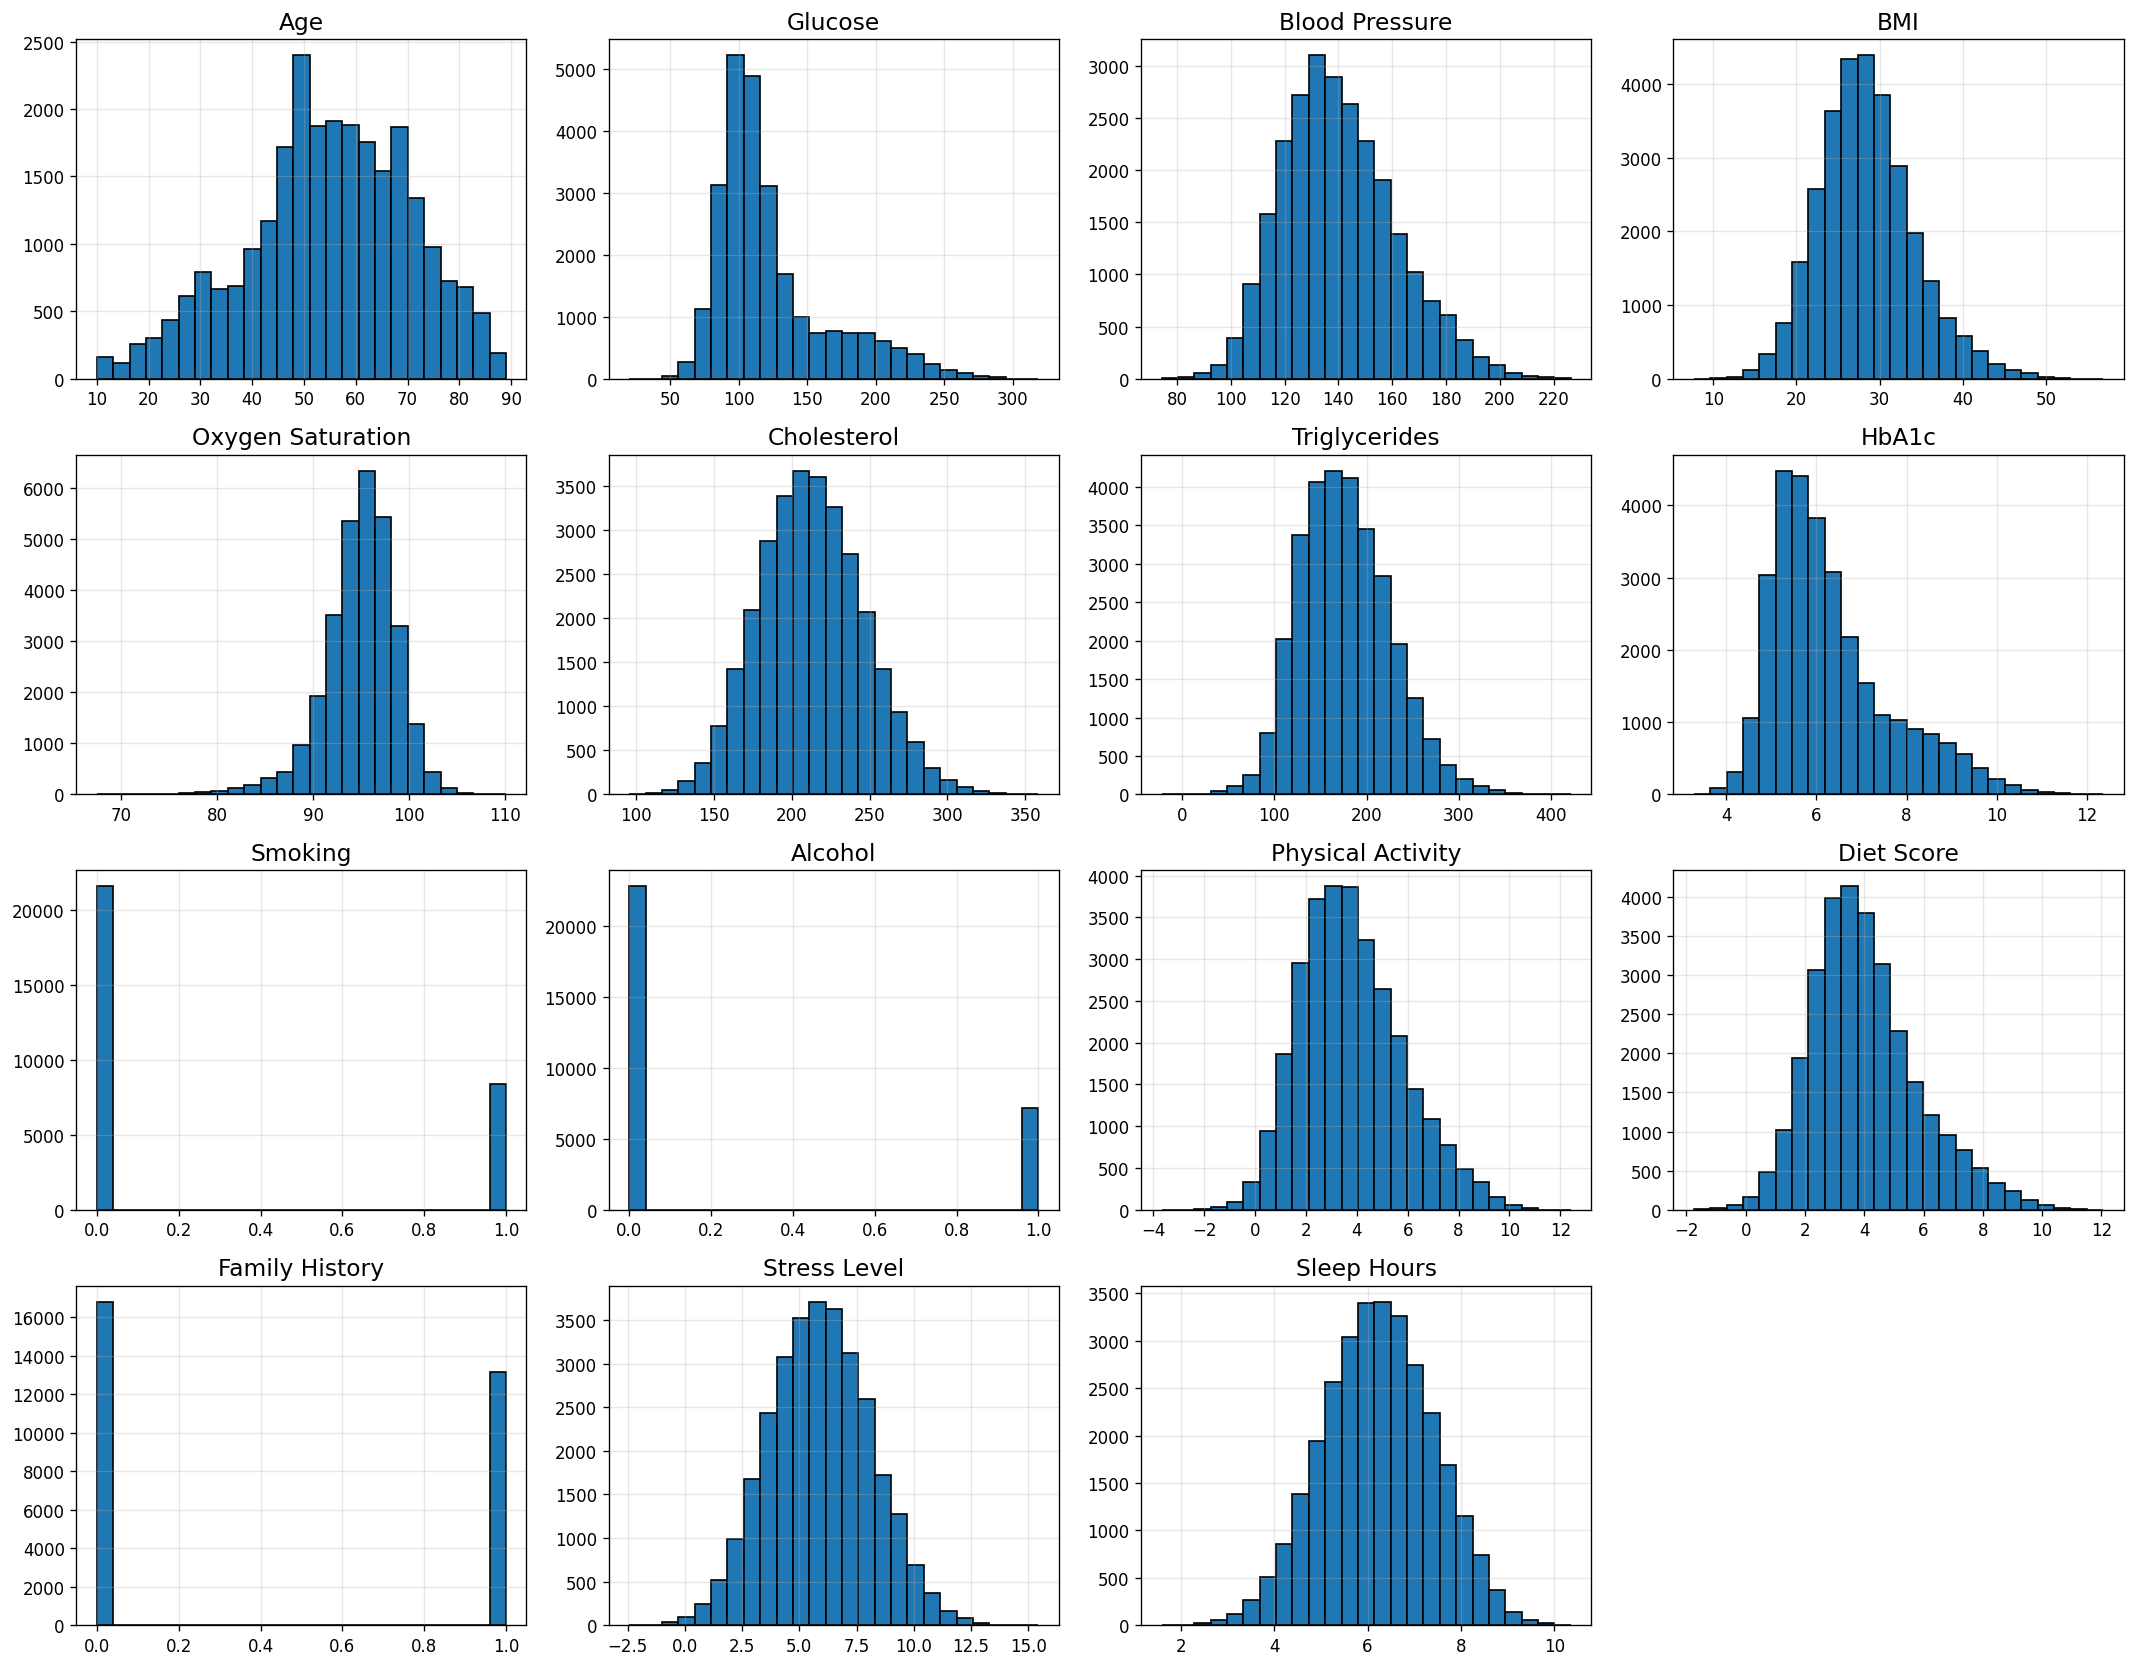

In [101]:
# Visualise numerical variables

fig, axes = plt.subplots(4, 4, figsize=(18, 14))

axes = axes.flatten()

for i, column in enumerate(numerical_columns):

    axes[i].hist(
        df[column].dropna(),
        bins=25,
        edgecolor="black"
    )

    axes[i].set_title(column)

# Remove unused axes

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

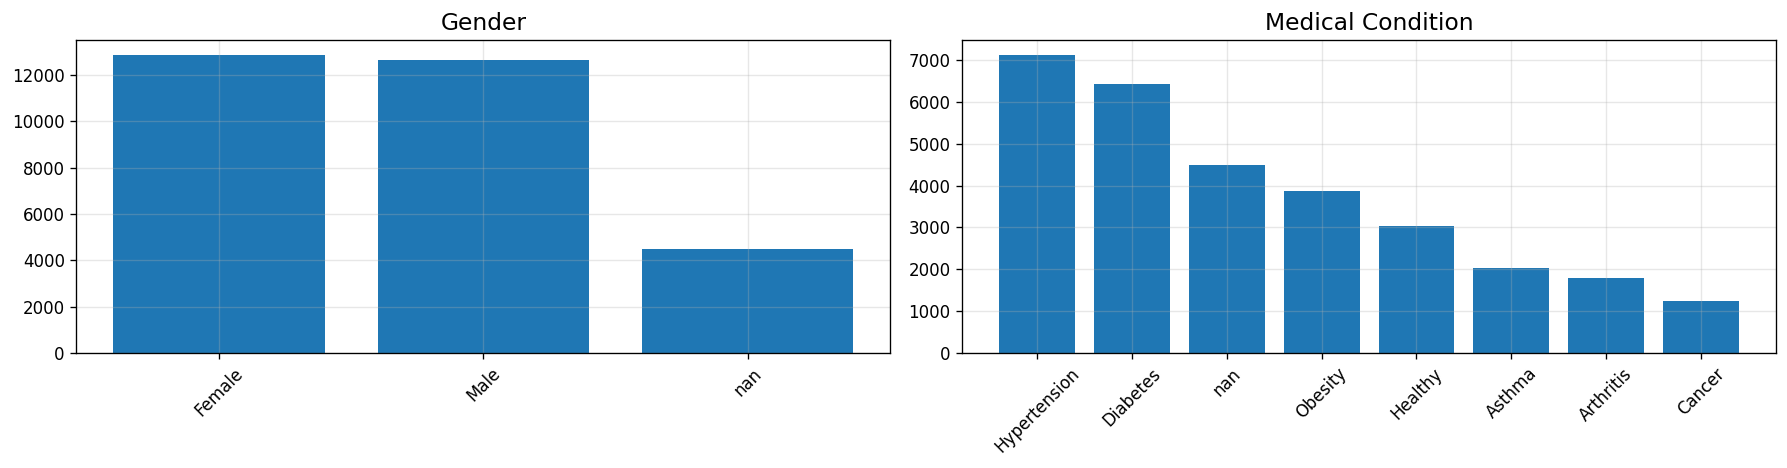

In [102]:
# Visualise categorical variables

fig, axes = plt.subplots(
    1,
    len(categorical_columns),
    figsize=(15,4)
)

for ax, column in zip(axes, categorical_columns):

    counts = df[column].value_counts(dropna=False)

    ax.bar(
        counts.index.astype(str),
        counts.values
    )

    ax.set_title(column)

    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

In [103]:
# Create a dataset for correlation analysis

correlation_df = df[numerical_columns.tolist() + [TARGET]]

# Calculate the correlation between each predictor and the target variable

correlation = (
    correlation_df
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values()
)

display(correlation.to_frame(name="Correlation"))

,Correlation
Sleep Hours,-0.25
Diet Score,-0.24
Physical Activity,-0.18
Oxygen Saturation,-0.15
BMI,0.00
Alcohol,0.03
Blood Pressure,0.04
Family History,0.05
Triglycerides,0.08
Smoking,0.09


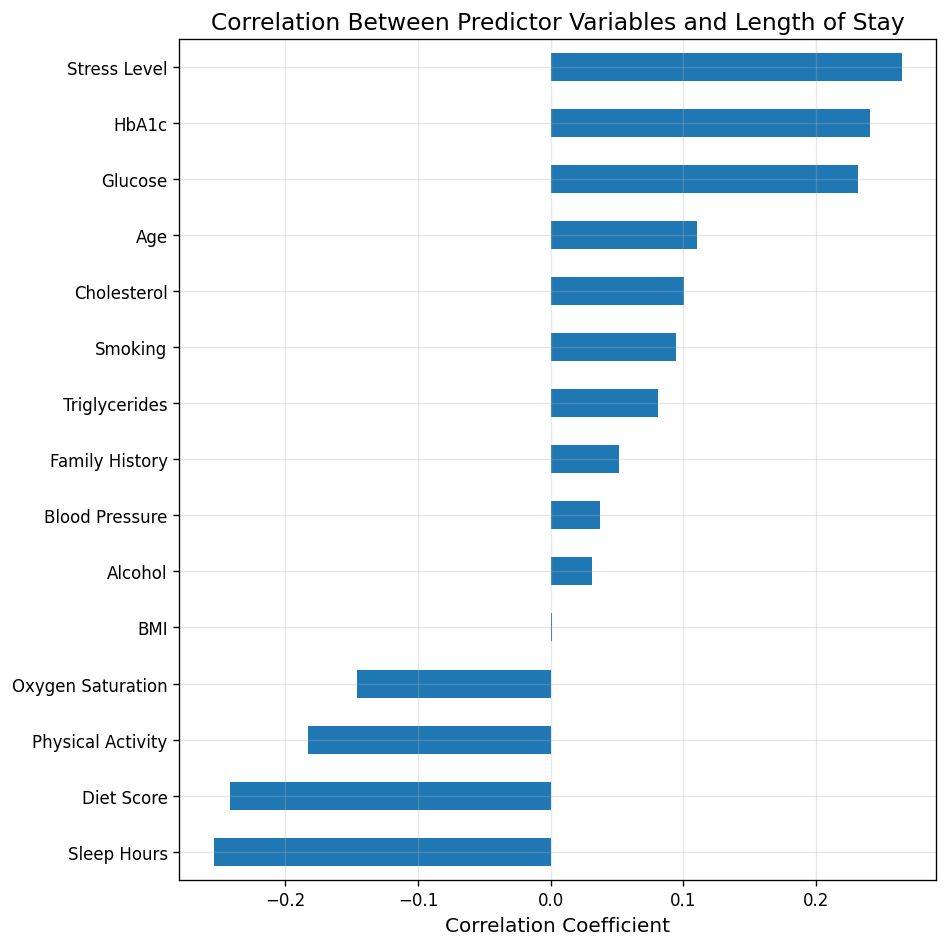

In [104]:
# Visualise the correlation between predictor variables and the target

fig, ax = plt.subplots(figsize=(8, 8))

correlation.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Correlation Between Predictor Variables and Length of Stay")
ax.set_xlabel("Correlation Coefficient")

plt.tight_layout()

plt.show()

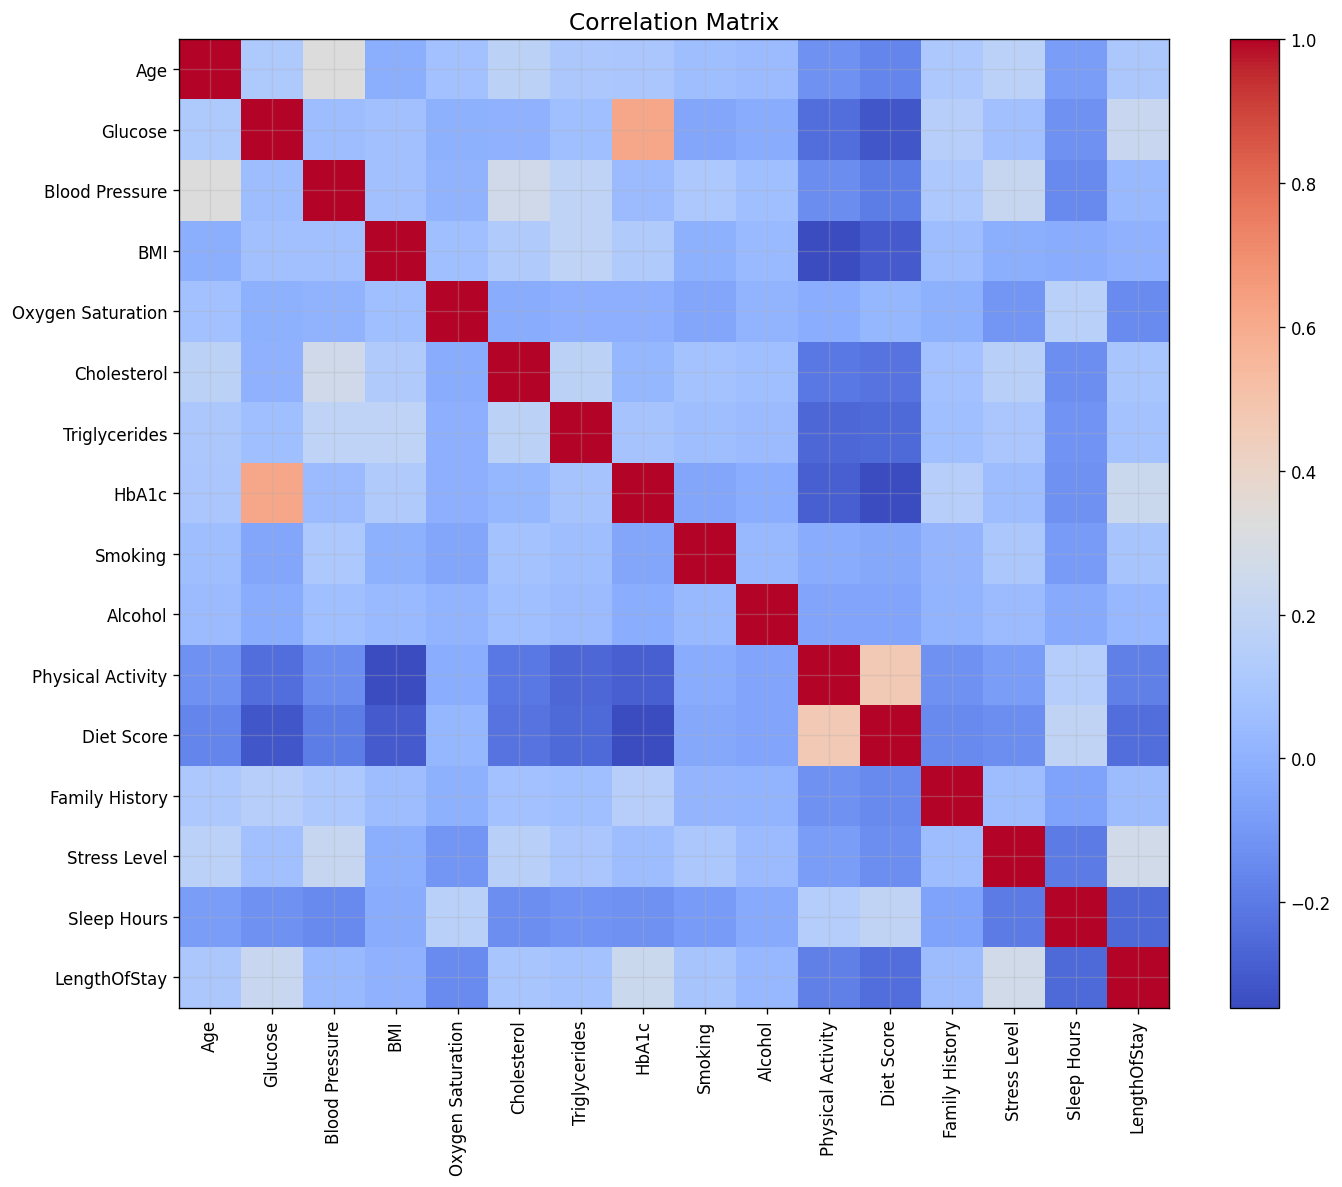

In [105]:
# Calculate the correlation matrix

correlation_matrix = correlation_df.corr()

# Visualise the correlation matrix

fig, ax = plt.subplots(figsize=(12, 10))

image = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=90)

ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_yticklabels(correlation_matrix.columns)

plt.colorbar(image)

ax.set_title("Correlation Matrix")

plt.tight_layout()

plt.show()

### Interpretation

The exploratory analysis shows that the dataset contains a good spread of patient characteristics and clinical measurements, providing sufficient variation for predictive modelling. The target variable, **LengthOfStay**, ranges from **1 to 19 days**, with an average stay of **4.41 days** and a median of **4 days**, indicating that most patients experience relatively short hospital stays while a smaller number remain admitted for longer periods.

The numerical variables generally follow reasonable distributions, although some variables contain a small number of extreme values. These will be investigated further during the preprocessing stage. The categorical variables are also well represented across their different classes, with hypertension and diabetes appearing more frequently than the other medical conditions.

The correlation analysis shows that no single predictor has a very strong relationship with hospital length of stay. However, variables such as **Stress Level**, **HbA1c**, **Glucose** and **Age** exhibit stronger positive relationships with the target, while **Sleep Hours**, **Diet Score**, **Physical Activity** and **Oxygen Saturation** show negative relationships. This suggests that hospital length of stay is influenced by multiple patient characteristics rather than a single factor, supporting the use of machine learning models capable of learning complex relationships between variables.

The correlation matrix also indicates that most predictor variables are not highly correlated with one another. Although a few related health indicators show moderate relationships, there is no evidence of widespread multicollinearity that would be expected to significantly affect model development.

#Data Preperation

### Prepare the Modelling Dataset

A working copy of the dataset is created to preserve the original data throughout the preprocessing stage. The predefined noise variables are then removed, leaving only variables that are relevant to predicting hospital length of stay.

In [106]:
# Create a working copy of the dataset

model_df = df.copy()

# Remove predefined noise variables

model_df = model_df.drop(columns=NOISE_COLUMNS)

# Display the dimensions of the modelling dataset

print(f"Number of Records : {model_df.shape[0]:,}")
print(f"Number of Variables: {model_df.shape[1]}")

display(model_df.head())

Number of Records : 30,000
Number of Variables: 18


,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.00,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.00,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.00,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.00,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.00,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64


The modelling dataset contains **30,000 patient records** and **18 variables** after removing the two predefined noise variables. The remaining variables consist of demographic, clinical and lifestyle-related features that are relevant to predicting hospital length of stay. The original dataset remains unchanged, while the modelling dataset will be used for all subsequent preprocessing and machine learning tasks.

### Handle Missing Values

Missing values are treated before model development to ensure that every observation can be used during training. Numerical variables are imputed using the median, while categorical variables are imputed using the most frequent category.

In [107]:
# Separate numerical and categorical variables

numerical_columns = model_df.select_dtypes(
    include=["int64", "float64"]
).columns.drop(TARGET)

categorical_columns = model_df.select_dtypes(
    include="object"
).columns

# Impute numerical variables using the median

for column in numerical_columns:
    model_df[column] = model_df[column].fillna(
        model_df[column].median()
    )

# Impute categorical variables using the mode

for column in categorical_columns:
    model_df[column] = model_df[column].fillna(
        model_df[column].mode()[0]
    )

# Confirm that no missing values remain

display(model_df.isnull().sum())

,0
Age,0
Gender,0
Medical Condition,0
Glucose,0
Blood Pressure,0
BMI,0
Oxygen Saturation,0
LengthOfStay,0
Cholesterol,0
Triglycerides,0


The missing values have been successfully addressed using median imputation for numerical variables and mode imputation for categorical variables. As shown above, all variables now contain complete observations, allowing the full dataset to be used for model training without losing any records.

### Encode Categorical Variables

Machine learning algorithms require numerical input. Therefore, the categorical variables are converted into numerical representations using one-hot encoding while avoiding redundant features.

In [108]:
# Apply one-hot encoding

model_df = pd.get_dummies(
    model_df,
    columns=categorical_columns,
    drop_first=True
)

# Display the transformed dataset

print(f"Number of Variables After Encoding: {model_df.shape[1]}")

display(model_df.head())

Number of Variables After Encoding: 23


,Age,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,Gender_Male,Medical Condition_Asthma,Medical Condition_Cancer,Medical Condition_Diabetes,Medical Condition_Healthy,Medical Condition_Hypertension,Medical Condition_Obesity
0,46.00,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,True,False,False,True,False,False,False
1,22.00,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,True,False,False,False,True,False,False
2,50.00,95.24,138.32,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,False,True,False,False,False,False,False
3,57.00,110.50,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,False,False,False,False,False,False,True
4,66.00,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,False,False,False,False,False,True,False


The categorical variables have been successfully transformed into numerical features using one-hot encoding. As a result, the number of variables increased from **18 to 23**, reflecting the creation of new binary indicator variables for the different medical conditions and gender categories. The dataset is now fully numerical and suitable for machine learning algorithms.

### Prepare Data for Machine Learning

The predictor variables and target variable are separated before scaling the numerical features. The dataset is then divided into training and testing sets to enable unbiased model evaluation.

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate predictor variables and target variable

X = model_df.drop(columns=TARGET)
y = model_df[TARGET]

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Scale predictor variables while preserving feature names

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Display the dataset dimensions

print(f"Training Set : {X_train_scaled.shape}")
print(f"Testing Set  : {X_test_scaled.shape}")

Training Set : (24000, 22)
Testing Set  : (6000, 22)


In [110]:
# Save the fitted scaler

import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


### Interpretation

The dataset has been successfully divided into training and testing sets using an **80:20 split**, resulting in **24,000 training records** and **6,000 testing records**. The predictor variables were standardised to ensure a consistent feature scale and to support machine learning algorithms that are sensitive to differences in variable magnitude. The processed dataset is now ready for predictive model development.

The dataset has been successfully prepared for predictive modelling. Irrelevant variables were removed, missing values were imputed, categorical variables were encoded and the predictor variables were standardised. The final dataset contains **22 predictor variables** and has been divided into training and testing sets for model development and evaluation.

# Predictive Model Development

### Prepare the Machine Learning Models

The regression models and evaluation metrics required for model development are imported. A reusable evaluation function is then defined to ensure that every model is assessed using the same performance measures.

In [111]:
# Import regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

# Import evaluation metrics

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import time

# Display the regression models included in the study

model_summary = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Description":[
        "Linear baseline model",
        "Single tree model",
        "Bagging ensemble model",
        "Boosting ensemble model",
        "Extreme gradient boosting model"
    ]

})

display(model_summary)

# Create a collection of regression models

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )

}

,Model,Description
0,Linear Regression,Linear baseline model
1,Decision Tree,Single tree model
2,Random Forest,Bagging ensemble model
3,Gradient Boosting,Boosting ensemble model
4,XGBoost,Extreme gradient boosting model


In [112]:
# Define a reusable function for evaluating regression models

def evaluate_model(
    model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
):

    start_time = time.time()

    model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.time() - start_time

    predictions = model.predict(
        X_test_scaled
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return mae, rmse, r2, training_time

### Train and Evaluate the Models

Each regression model is trained using the training dataset and evaluated on the testing dataset. The evaluation results are stored for comparison using the same performance metrics.

In [113]:
# Train and evaluate each regression model

results = []

for name, model in models.items():

    mae, rmse, r2, training_time = evaluate_model(
    model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

    results.append({

        "Model": name,
        "MAE": round(mae,3),
        "RMSE": round(rmse,3),
        "R²": round(r2,3),
        "Training Time (s)": round(training_time,3)

    })

# Create the model comparison table

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results_df.insert(
    0,
    "Rank",
    results_df.index + 1
)

display(results_df)

,Rank,Model,MAE,RMSE,R²,Training Time (s)
0,1,Random Forest,1.33,1.77,0.59,40.41
1,2,Gradient Boosting,1.33,1.78,0.59,8.54
2,3,Linear Regression,1.34,1.81,0.58,0.01
3,4,XGBoost,1.36,1.83,0.56,0.45
4,5,Decision Tree,1.73,2.50,0.19,0.85


All five regression models were successfully trained and evaluated using the same testing dataset. The results show that the **Random Forest**, **Gradient Boosting**, **Linear Regression** and **XGBoost** models achieved comparable predictive performance, with RMSE values ranging from **1.77 to 1.83** and R² scores between **0.56 and 0.59**. In contrast, the **Decision Tree** model recorded the highest prediction error (RMSE = **2.50**) and the lowest explanatory power (R² = **0.19**), making it the weakest-performing model in this study.

### Compare Model Performance

The evaluation results are visualised to compare the predictive performance of each regression model across the selected evaluation metrics.

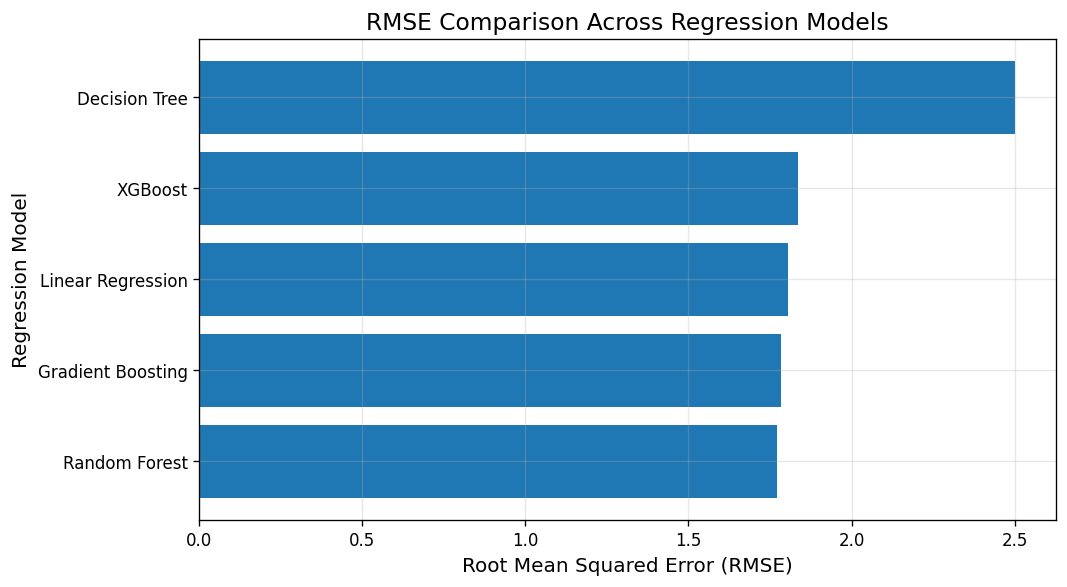

In [114]:
# Compare model performance using RMSE

results_sorted = results_df.sort_values("RMSE")

plt.figure(figsize=(9,5))

plt.barh(
    results_sorted["Model"],
    results_sorted["RMSE"]
)

plt.title("RMSE Comparison Across Regression Models")
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Regression Model")

plt.tight_layout()

plt.show()

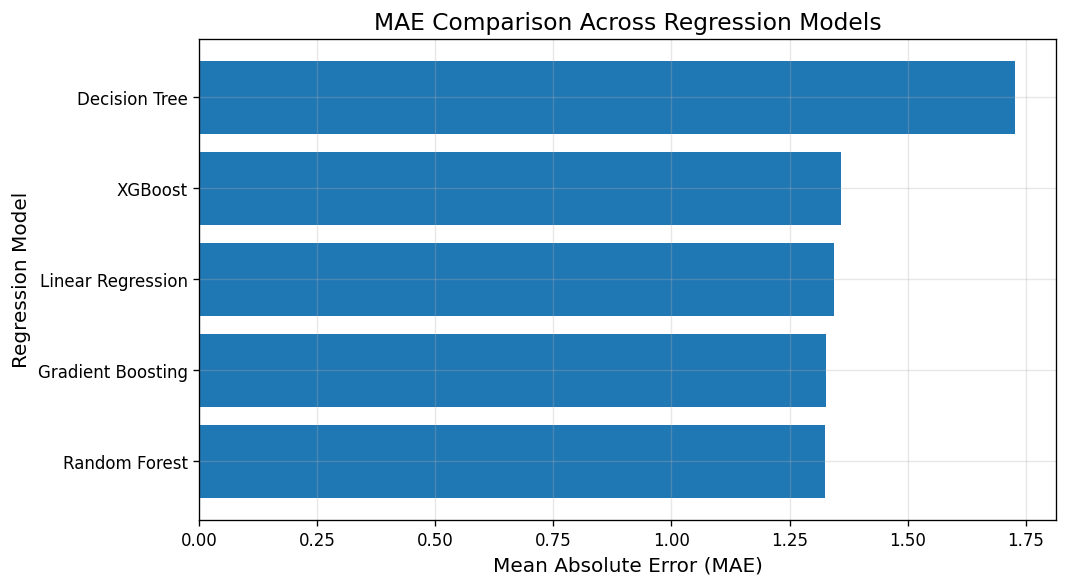

In [115]:
# Compare model performance using MAE

results_sorted = results_df.sort_values("MAE")

plt.figure(figsize=(9,5))

plt.barh(
    results_sorted["Model"],
    results_sorted["MAE"]
)

plt.title("MAE Comparison Across Regression Models")
plt.xlabel("Mean Absolute Error (MAE)")
plt.ylabel("Regression Model")

plt.tight_layout()

plt.show()

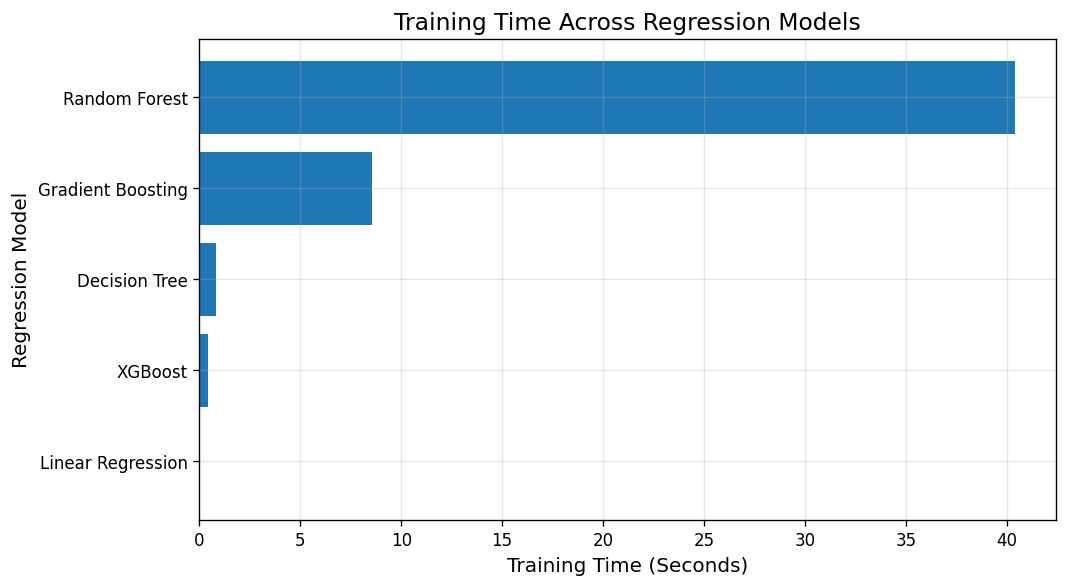

In [116]:
# Compare model training time

results_sorted = results_df.sort_values("Training Time (s)")

plt.figure(figsize=(9,5))

plt.barh(
    results_sorted["Model"],
    results_sorted["Training Time (s)"]
)

plt.title("Training Time Across Regression Models")
plt.xlabel("Training Time (Seconds)")
plt.ylabel("Regression Model")

plt.tight_layout()

plt.show()

The comparison charts show that the four advanced regression models produced similar levels of predictive accuracy, while the Decision Tree model performed noticeably worse. **Random Forest** achieved the lowest RMSE (**1.77**) and shared the lowest MAE (**1.33**) with **Gradient Boosting**, indicating the highest prediction accuracy. Although Random Forest required the longest training time (**42.06 seconds**), the improvement in predictive performance justified its selection as the final model for this study.

### Select the Best Performing Model

The model with the lowest prediction error and strongest goodness-of-fit is selected for explainability analysis and deployment within the Streamlit application.

In [117]:
# Select the best-performing model

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

best_model.fit(
    X_train_scaled,
    y_train
)

print(f"Best Performing Model: {best_model_name}")

# Display the selected model summary

display(results_df.iloc[[0]])

Best Performing Model: Random Forest


,Rank,Model,MAE,RMSE,R²,Training Time (s)
0,1,Random Forest,1.33,1.77,0.59,40.41


In [118]:
# Save the trained model

import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

# Save the model comparison table

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model and evaluation results saved successfully.")

Model and evaluation results saved successfully.


### Interpretation

Based on the evaluation metrics, **Random Forest** was selected as the best-performing regression model. It achieved the lowest RMSE, one of the lowest MAE values and the highest R² score among the evaluated models. Despite requiring the longest training time, its superior predictive performance made it the most suitable model for the explainability analysis and deployment within the Streamlit decision-support application.

# Model Interpretation and Explainability

### Prepare Explainability Analysis

The SHAP library is imported and configured to generate explanations for the selected Random Forest model. An explainer object is created to estimate the contribution of each predictor variable to the model's predictions.

In [119]:
import shap

shap.initjs()

X_test_sample = X_test_scaled.sample(
    n=100,
    random_state=42
)

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values generated for {len(X_test_sample)} test records.")

SHAP values generated for 100 test records.


The SHAP explainer was successfully created for the selected Random Forest model. The calculated SHAP values quantify the contribution of every predictor variable to each prediction, providing the foundation for interpreting how the model reaches its decisions.

### Global Model

Global model examines the overall behaviour of the Random Forest model across all patients in the testing dataset. The SHAP summary plot and feature importance chart are used to identify the variables that contribute most to hospital length of stay predictions.

In [120]:
# Create display-friendly feature names

X_test_sample_display = X_test_sample.rename(columns={

    "Medical Condition_Cancer": "Cancer",

    "Medical Condition_Diabetes": "Diabetes",

    "Medical Condition_Healthy": "Healthy",

    "Medical Condition_Hypertension": "Hypertension",

    "Medical Condition_Asthma": "Asthma",

    "Medical Condition_Obesity": "Obesity",

    "Gender_Male": "Male"

})

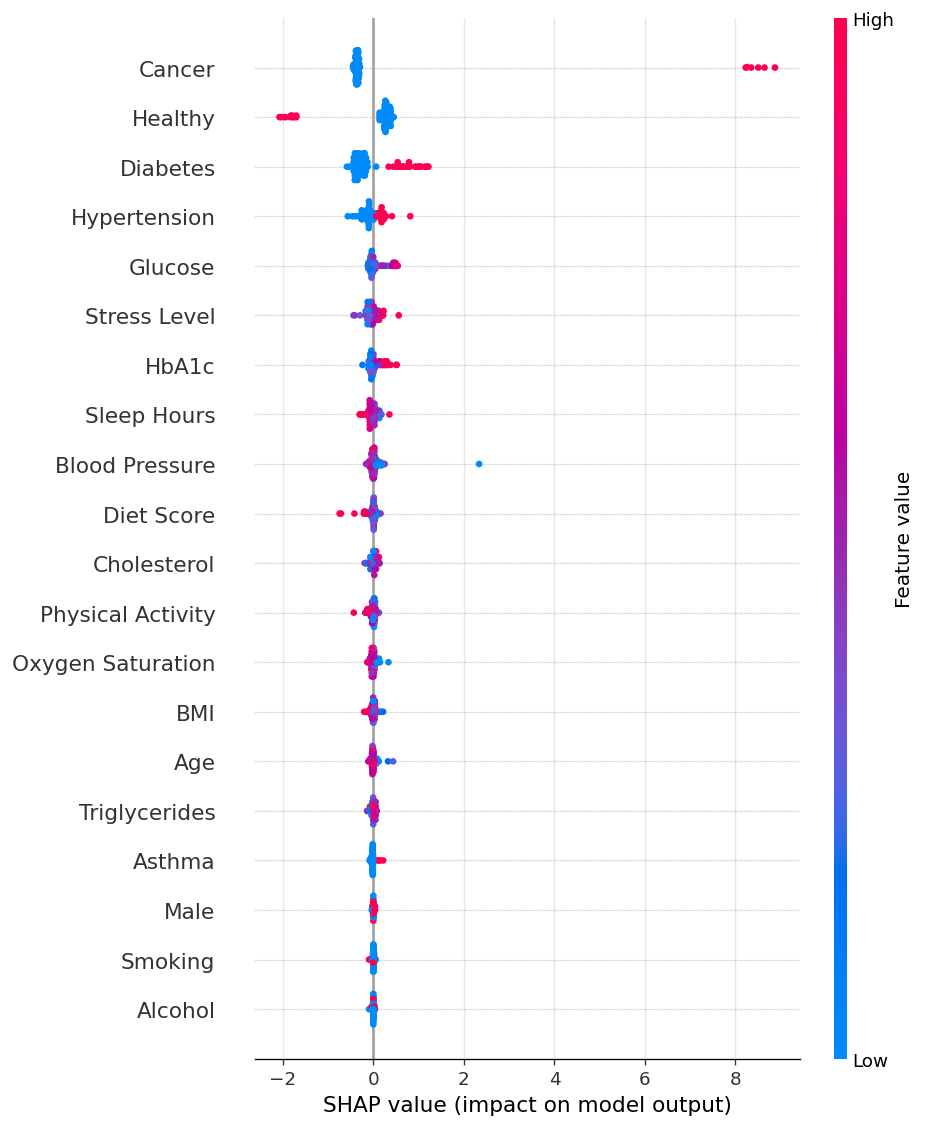

In [121]:
# Generate SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_sample_display
)

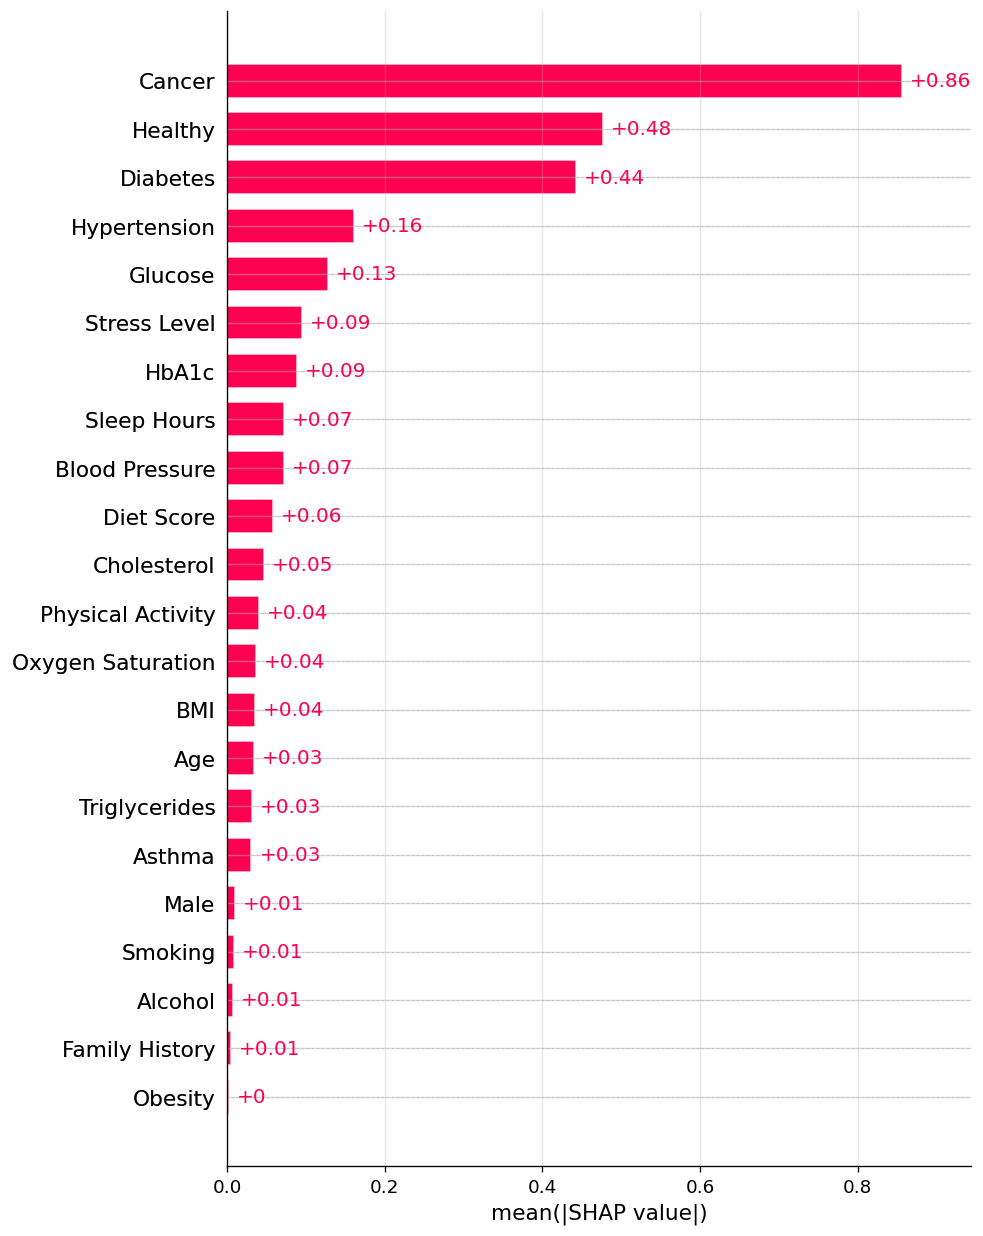

In [122]:
# Generate SHAP feature importance chart

shap.plots.bar(

    shap.Explanation(

        values=shap_values,

        base_values=np.repeat(
            explainer.expected_value,
            len(X_test_sample_display)
        ),

        data=X_test_sample_display,

        feature_names=X_test_sample_display.columns

    ),

    max_display=len(X_test_sample_display.columns)

)

#### Interpretation

The SHAP visualisations provide an overall explanation of how the Random Forest model predicts hospital length of stay across the sampled patients. The results show that a patient's medical condition has the greatest influence on the model's predictions, with Cancer, Healthy, Diabetes and Hypertension emerging as the most important features. This indicates that the patient's underlying diagnosis plays a major role when estimating the expected duration of hospitalisation.

Among the continuous variables, Glucose, Stress Level and HbA1c were the strongest contributors to the model's predictions, while Blood Pressure and Sleep Hours also showed noticeable influence. In contrast, variables such as Smoking, Alcohol and Gender had relatively small effects on the final prediction. Overall, the model appears to rely primarily on diagnosis and key clinical measurements when predicting hospital length of stay.

### Local Model

This entails how the model generated a prediction for an individual patient. A SHAP waterfall plot is used to show how each predictor variable contributes towards increasing or decreasing the predicted hospital length of stay.

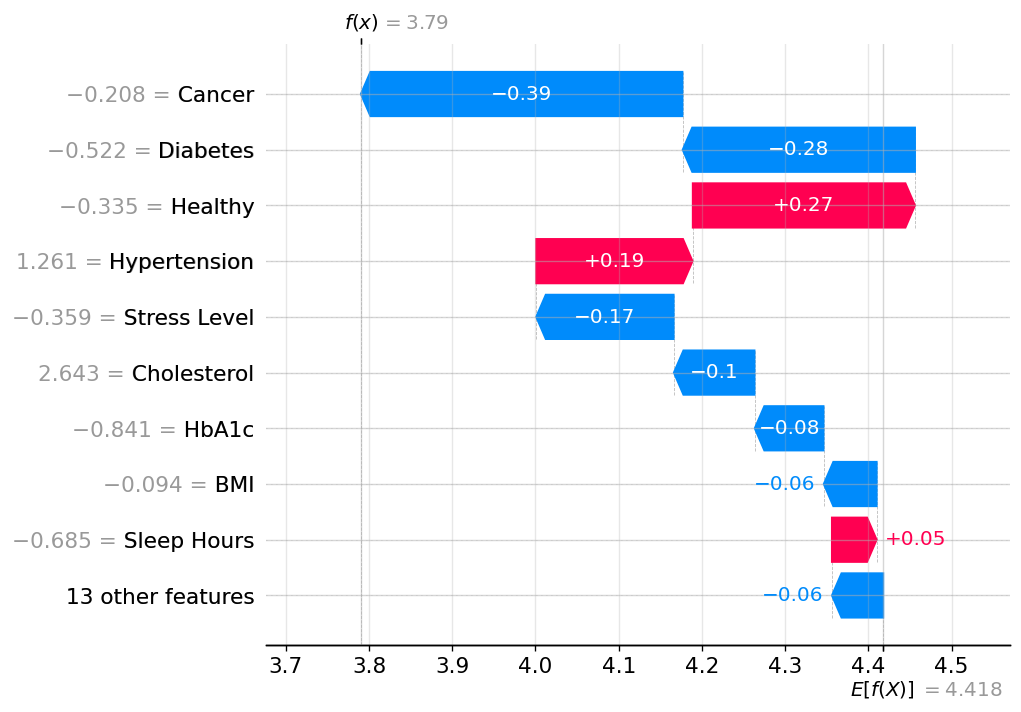

In [123]:
# Select a patient

patient = 0

# Generate waterfall plot

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[patient],

        base_values=explainer.expected_value,

        data=X_test_sample_display.iloc[patient],

feature_names=X_test_sample_display.columns

    )

)

#### Interpretation

The waterfall plot explains how the Random Forest model generated the prediction for a single patient. The prediction begins from the model's average expected length of stay and is then adjusted based on the patient's individual characteristics. Some variables increase the predicted length of stay, while others reduce it, with the final prediction reflecting the combined effect of all contributing features.

For this patient, the model predicted a hospital stay of approximately **3.79 days**, which is lower than the model's average prediction of **4.42 days**. The plot clearly shows how each variable contributed to this final prediction, making the model's decision easier to understand and interpret.

#Save Model for Deployment

In [124]:
# Export deployment files

import os
import joblib
from google.colab import files

# Create deployment folder

os.makedirs("artifacts", exist_ok=True)

# Create deployment package

deployment_package = {

    "model": best_model,

    "scaler": scaler,

    "feature_names": X.columns.tolist(),

    "results": results_df,

    "target_variable": TARGET,

    "medical_conditions": sorted(
        df["Medical Condition"].dropna().unique().tolist()
    ),

    "gender_options": sorted(
        df["Gender"].dropna().unique().tolist()
    )

}

# Save deployment package

joblib.dump(
    deployment_package,
    "artifacts/hospital_los_predictor.pkl"
)

# Save supporting files

model_df.to_csv(
    "artifacts/model_dataset.csv",
    index=False
)

results_df.to_csv(
    "artifacts/model_results.csv",
    index=False
)

# Display exported files

print("Deployment files created successfully.\n")

for file in os.listdir("artifacts"):
    print(f"• {file}")

# Download deployment files

files.download("artifacts/hospital_los_predictor.pkl")
files.download("artifacts/model_dataset.csv")
files.download("artifacts/model_results.csv")

Deployment files created successfully.

• model_dataset.csv
• model_results.csv
• hospital_los_predictor.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [125]:
import os

size_mb = os.path.getsize("artifacts/hospital_los_predictor.pkl") / (1024 * 1024)

print(f"Deployment package size: {size_mb:.2f} MB")

Deployment package size: 95.92 MB
